# newton's law of cooling

<img src="image/FLIR_test_tube_water.jpg" width="250" height="auto" style="display: block; margin: auto;" />

<img src="image/newtons_law_of_cooling.png" width="100" height="auto" style="display: block; margin: auto;" />

In [1]:
from sympy import init_session
init_session()
E, k, c, C = symbols('E k c C', real=True)

IPython console for SymPy 1.14.0 (Python 3.14.5-64-bit) (ground types: python)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.14.0/



<p>"Newton's law of cooling is a physical law which states that the rate of heat loss of a body is directly proportional to the difference in the temperatures between the body and its environment. The law is frequently qualified to include the condition that the temperature difference is small and the nature of heat transfer mechanism remains the same. As such, it is equivalent to a statement that the heat transfer coefficient, which mediates between heat losses and temperature differences, is a constant.
</p><p>"When stated in terms of temperature differences, Newton's law...results in a simple differential equation expressing temperature-difference as a function of time. The solution to that equation describes an exponential decrease of temperature-difference over time."
</p>--- wikipedia

<p>The "simple differential equation expressing temperature-difference as a function of time" that we'll use is:</p>
<p style="margin-left: 15px;">$dy/dt = k*(y - E)$, where:</p>
<p style="margin-left: 25px;">
$t =$ time;<br>
$y =$ temperature of cooling mass;<br>
$E =$ temperature of environment; and<br>
$k =$ the proportionality constant.</p>
<p>We wish to find an algebraic equation that allows us to solve for $y$, given $t$. To do that requires us to first solve the differential equation and solving for $k$, given $E$.

<p>we start by giving E a numeric value,
then collecting all the y terms on one side of the equation, and everything else on the other:</p>
<p>$1 / (y - E) \: dy = k \: dt$</p>
<p></p>
<p>* This application of calculus we're using to derive our model was presented by
<br>Professor Bruce H. Edwards in <i>Understanding Calculus</i>, "Lesson 36: Applications of Differential Equations, Newton's Law of Cooling". The Great Courses, 2010.</p>

In [2]:
# now integrate both sides:
expr1 = Integral(1 / (y - E), y)

In [3]:
expr1 = expr1.doit(); expr1

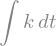

In [4]:
expr2 = Integral(k, t); expr2

In [5]:
expr2 = expr2.doit(); expr2

In [6]:
expr2  = expr2 + c; expr2

In [7]:
expr1 = exp(expr1); expr1

In [8]:
expr2 = exp(expr2); expr2

In [9]:
factor(expr2)

Let C $= e^{c}$. Then:

In [10]:
expr2 = C * simplify(expr2 / exp(c)); expr2

# our model

In [11]:
# Setting LHS = 0, RHS becomes:
expr = E + expr2 - y; expr

## by substituting values for variables in our model and applying a little algebra by hand, 
## we can solve for either time t, given temp of mass, or for temp of mass, given time t

In [26]:
# Setting t=0 and y = temp of mass at t=0, we get the value of C.
num_vals = {t:0, y:94.1, E:25.21}
expr.subs(num_vals)

In [27]:
# Setting t = first reading of temp of mass as it cools, and y = temp at that time,
# we're left with k:
num_vals = {t:120, y:90, E:25.21, C:68.89}
soln = expr.subs(num_vals); soln

In [15]:
simplify(log(exp(120 * k)))

In [16]:
# k
log(64.79/68.89) / 120

In [28]:
# verifying that this is indeed the value of k. if true, evaluation with substituted values should return 0.
expr.subs({t:120, y:90, E:25.21, C:68.89, k:log(64.79/68.89) / 120})

## the value of a model is its power to predict.
## we can now solve for time t, given temp of mass y; or for temp of mass y, given time t

In [29]:
# to solve for time t in this model, we first provide value of temp of mass, y, at time t
num_vals = {y:80, E:25.21, C:68.89, k:log(64.79/68.89) / 120}
expr.subs(num_vals)

In [30]:
# we then use algebra to collect all terms but t on the LHS of expr. evaluating the LHS returns time t
log(54.79/68.89) / (log(54.79/68.89) / 120)

In [31]:
# to solve for temp of mass y at time t in this model, we provide time t:
num_vals = {t:447.86, E:25.21, C:68.89, k:log(64.79/68.89) / 120}
expr.subs(num_vals)